# Student Test Score Prediction

The aim of this project is to predict a student's final test score using information available earlier, especially the pretest score and basic information about the school and teaching environment.

From an educational and business perspective, the model can support teachers and schools in identifying students who may need additional help before the final test.

The model should not make automatic decisions. It should be treated as a decision-support tool for teachers.


# Import Libraries


In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42


# Load Data


In [2]:
test_scores = pd.read_csv("test_scores.csv")
test_scores.head()


,school,school_setting,school_type,classroom,teaching_method,n_student,student_id,gender,lunch,pretest,posttest
0,ANKYI,Urban,Non-public,6OL,Standard,20.0,2FHT3,Female,Does not qualify,62.0,72.0
1,ANKYI,Urban,Non-public,6OL,Standard,20.0,3JIVH,Female,Does not qualify,66.0,79.0
2,ANKYI,Urban,Non-public,6OL,Standard,20.0,3XOWE,Male,Does not qualify,64.0,76.0
3,ANKYI,Urban,Non-public,6OL,Standard,20.0,556O0,Female,Does not qualify,61.0,77.0
4,ANKYI,Urban,Non-public,6OL,Standard,20.0,74LOE,Male,Does not qualify,64.0,76.0


* `school` - Identifier or name of the school attended by the student.
* `school_setting`	- Type of area in which the school is located, for example urban, suburban, or rural.
* `school_type`	- Type of school, such as public or non-public.
* `classroom`	- Identifier of the classroom or class group to which the student belongs.
* `teaching_method`	- Teaching method used in the classroom, for example standard or experimental.
* `n_student` -	Number of students in the classroom.
* `student_id`	- Unique identifier assigned to each student.
gender	Student’s gender.
* `lunch`	- Type of school lunch program assigned to the student, for example free/reduced or standard.
* `pretest` - Student’s score before the teaching period or intervention. It represents baseline knowledge.
* `posttest` - Student’s score after the teaching period

In [5]:
test_scores.shape


(2133, 11)

The dataset contains 2133 observations and 11 columns. Each row describes one student.


# Preliminary Data Analysis


In [6]:
test_scores.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school           2133 non-null   object 
 1   school_setting   2133 non-null   object 
 2   school_type      2133 non-null   object 
 3   classroom        2133 non-null   object 
 4   teaching_method  2133 non-null   object 
 5   n_student        2133 non-null   float64
 6   student_id       2133 non-null   object 
 7   gender           2133 non-null   object 
 8   lunch            2133 non-null   object 
 9   pretest          2133 non-null   float64
 10  posttest         2133 non-null   float64
dtypes: float64(3), object(8)
memory usage: 183.4+ KB


In [8]:
test_scores.describe().T


,count,mean,std,min,25%,50%,75%,max
n_student,2133.0,22.796531,4.228893,14.0,20.0,22.0,27.0,31.0
pretest,2133.0,54.955931,13.563101,22.0,44.0,56.0,65.0,93.0
posttest,2133.0,67.102203,13.986789,32.0,56.0,68.0,77.0,100.0


In [9]:
print(test_scores.isnull().sum())


school             0
school_setting     0
school_type        0
classroom          0
teaching_method    0
n_student          0
student_id         0
gender             0
lunch              0
pretest            0
posttest           0
dtype: int64


There are no missing `NaN` values in the dataset, so no missing-value removal or imputation is required.

However, imputation is still included in the pipeline as a safeguard for future data.


In [10]:
print("Number of duplicates:", test_scores.duplicated().sum())
print("Number of unique student_id:", test_scores["student_id"].nunique())


Number of duplicates: 0
Number of unique student_id: 2133


There are no fully duplicated rows, and every `student_id` is unique.


# Target Distribution


In [11]:
test_scores["posttest"].describe()


,posttest
count,2133.000000
mean,67.102203
std,13.986789
min,32.000000
25%,56.000000
50%,68.000000
75%,77.000000
max,100.000000


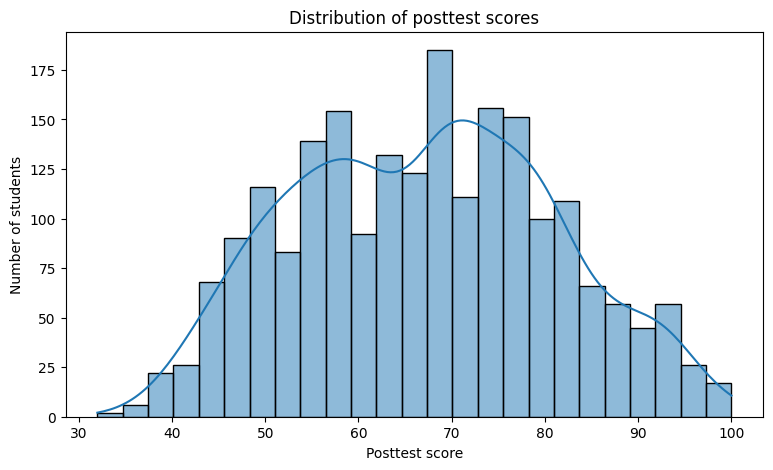

In [12]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=test_scores,
    x="posttest",
    bins=25,
    kde=True
)

plt.title("Distribution of posttest scores")
plt.xlabel("Posttest score")
plt.ylabel("Number of students")
plt.show()


Posttest scores are varied. The median is 68 points, and half of the students score between 56 and 77 points.

The regression model will predict a specific number of points rather than only a low/high score category.


# Relationship Between Pretest and Posttest


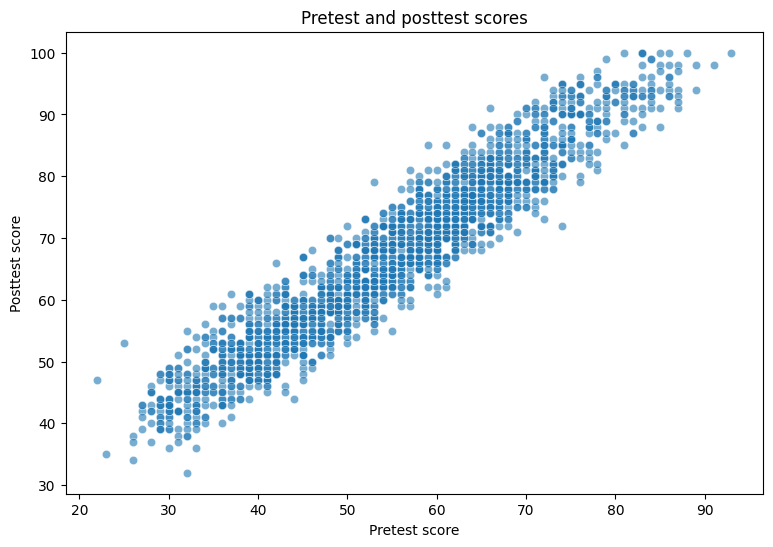

In [13]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=test_scores,
    x="pretest",
    y="posttest",
    alpha=0.6
)

plt.title("Pretest and posttest scores")
plt.xlabel("Pretest score")
plt.ylabel("Posttest score")
plt.show()


In [14]:
test_scores[["pretest", "posttest"]].corr()


,pretest,posttest
pretest,1.000000,0.950884
posttest,0.950884,1.000000


Pretest and posttest scores are very strongly positively correlated. The correlation coefficient is approximately 0.95.

This means that the pretest score is the strongest candidate for predicting the final score. Students with higher initial scores usually also achieve higher final scores.


# Posttest Score by Teaching Method


In [15]:
teaching_method_results = (
    test_scores
    .groupby("teaching_method")["posttest"]
    .agg(["mean", "median", "count"])
)

teaching_method_results


,mean,median,count
teaching_method,,,
Experimental,72.982895,75.0,760
Standard,63.847050,63.0,1373


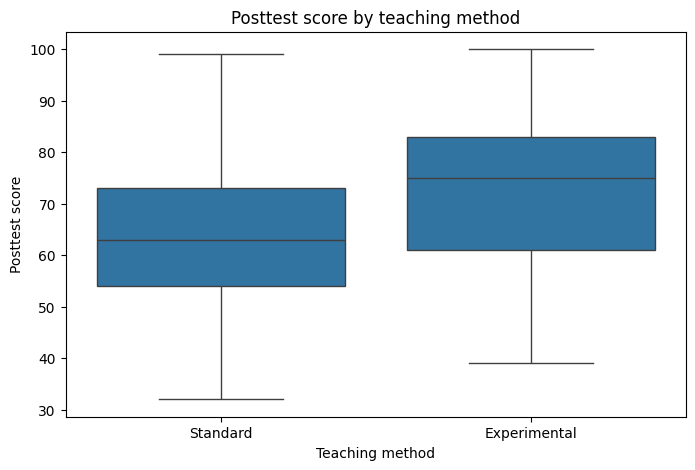

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=test_scores,
    x="teaching_method",
    y="posttest"
)

plt.title("Posttest score by teaching method")
plt.xlabel("Teaching method")
plt.ylabel("Posttest score")
plt.show()


Students using the experimental method score about 73 points on average, while students using the standard method score about 64 points.

This is a clear difference, but it does not prove that the experimental method itself causes higher scores. The groups may also differ in initial ability, school, or other characteristics.


# Posttest Score by Lunch Status


In [17]:
lunch_results = (
    test_scores
    .groupby("lunch")["posttest"]
    .agg(["mean", "median", "count"])
)

lunch_results


,mean,median,count
lunch,,,
Does not qualify,74.375309,74.0,1215
Qualifies for reduced/free lunch,57.476035,55.0,918


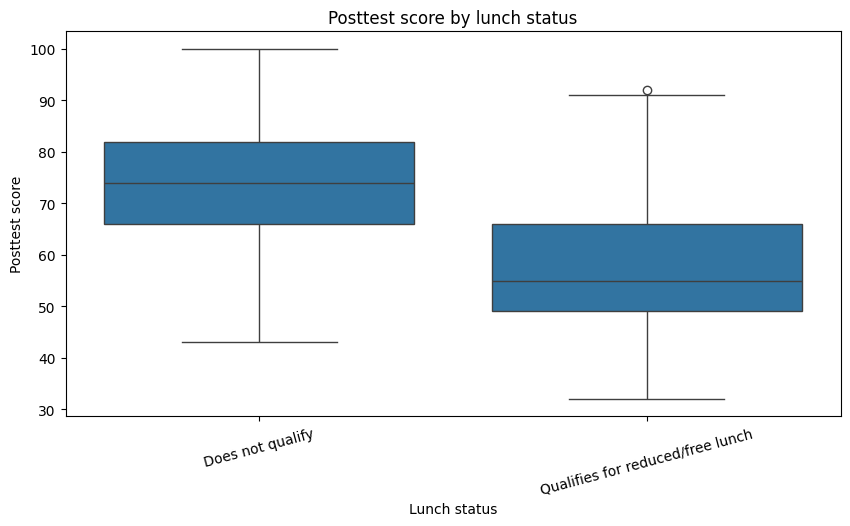

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=test_scores,
    x="lunch",
    y="posttest"
)

plt.title("Posttest score by lunch status")
plt.xlabel("Lunch status")
plt.ylabel("Posttest score")
plt.xticks(rotation=15)
plt.show()


Students who do not qualify for reduced or free lunch score about 74 points on average. Students who qualify score about 57 points on average.

This variable may act as an indirect indicator of socioeconomic conditions, but it should not be interpreted as a direct cause of performance.


# Posttest Score by School Setting


In [19]:
school_setting_results = (
    test_scores
    .groupby("school_setting")["posttest"]
    .agg(["mean", "median", "count"])
)

school_setting_results


,mean,median,count
school_setting,,,
Rural,64.050980,67.0,510
Suburban,76.037657,76.0,717
Urban,61.748344,59.0,906


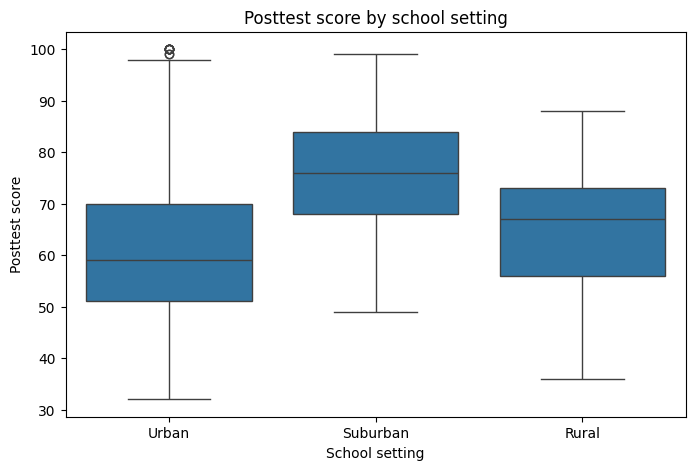

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=test_scores,
    x="school_setting",
    y="posttest"
)

plt.title("Posttest score by school setting")
plt.xlabel("School setting")
plt.ylabel("Posttest score")
plt.show()


Students from suburban schools achieve the highest average score, about 76 points. Urban and rural school results are lower.

However, these differences may be related to other variables, so the model should analyse multiple features together.


# Class Size and Score


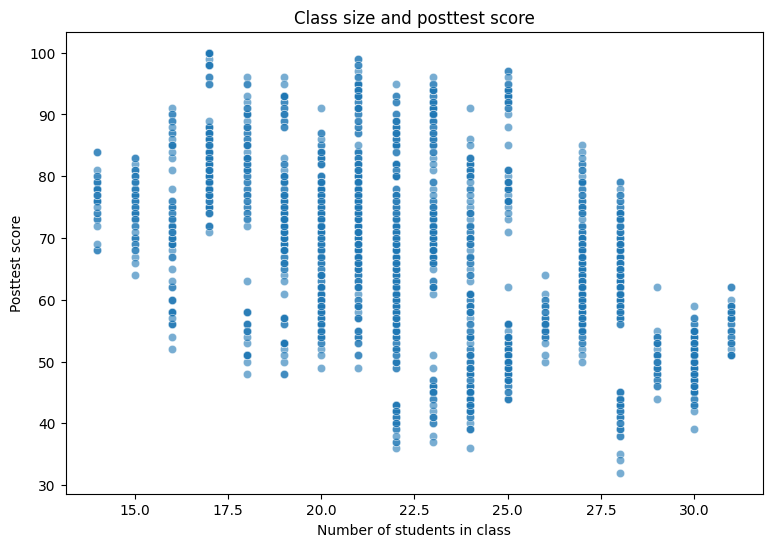

In [21]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=test_scores,
    x="n_student",
    y="posttest",
    alpha=0.6
)

plt.title("Class size and posttest score")
plt.xlabel("Number of students in class")
plt.ylabel("Posttest score")
plt.show()


In [22]:
test_scores[["n_student", "posttest"]].corr()


,n_student,posttest
n_student,1.000000,-0.504886
posttest,-0.504886,1.000000


Class size is moderately negatively correlated with posttest score. The correlation is approximately -0.50.

Smaller classes are associated with higher scores, but this relationship may also be related to school type, location, or other factors.


# Data Preparation


`student_id` is not used because it is only an identifier.

`school` and `classroom` are also not used as ordinary model features. They identify specific schools and classes. The model could memorise their results instead of learning more general relationships.

The data is split by school. Schools in the test set do not appear in the training set. This checks whether the model can generalise to new schools.


In [23]:
categorical_columns = [
    "school_setting",
    "school_type",
    "teaching_method",
    "gender",
    "lunch"
]

numerical_columns = [
    "n_student",
    "pretest"
]

features = categorical_columns + numerical_columns

X = test_scores[features]
y = test_scores["posttest"]
groups = test_scores["school"]


In [24]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_index, test_index = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

groups_train = groups.iloc[train_index]
groups_test = groups.iloc[test_index]

print(
    "Liczba szkół występujących w obu zbiorach:",
    len(set(groups_train).intersection(set(groups_test)))
)


Liczba szkół występujących w obu zbiorach: 0


The number of schools appearing in both the training and test sets is 0.


In [25]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])


# Selection of Metrics


The following metrics are used:

- **MAE** – the average absolute error in score points. It is the easiest to interpret because it shows how many points the model is wrong by on average.
- **RMSE** – also measures error in points but penalises large errors more strongly.
- **R²** – shows how much of the variation in final scores is explained by the model.

MAE is the main metric because it can be directly interpreted in the test score scale.


# Model Training


In [26]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])


In [27]:
models = {
    "Dummy Regressor": dummy_model,
    "Linear Regression": linear_model,
    "Ridge": ridge_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

model_results = []
model_predictions = {}

for model_name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    model_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(
            y_test,
            prediction
        ),
        "RMSE": mean_squared_error(
            y_test,
            prediction
        ) ** 0.5,
        "R2": r2_score(
            y_test,
            prediction
        )
    })

    model_predictions[model_name] = prediction

model_results = pd.DataFrame(model_results)
model_results.sort_values("MAE")


,Model,MAE,RMSE,R2
1,Linear Regression,2.585104,3.256220,0.958360
2,Ridge,2.585155,3.256361,0.958356
3,Random Forest,3.490548,4.714096,0.912727
4,Gradient Boosting,3.582155,4.737866,0.911844
0,Dummy Regressor,13.777874,16.087072,-0.016340


Linear Regression achieves the best result.

On the test set, the model obtains approximately:

- MAE: 2.59 points,
- RMSE: 3.26 points,
- R²: 0.96.

This means that the model is wrong by about 2.6 test points on average.

More complex models, such as Random Forest and Gradient Boosting, perform worse. In this dataset, the relationship between pretest and posttest is so strong and close to linear that the simple model works best.


# Selected Model Evaluation


In [28]:
selected_model = linear_model
selected_prediction = model_predictions["Linear Regression"]

results = X_test.copy()

results["ActualPosttest"] = y_test.values
results["PredictedPosttest"] = selected_prediction
results["AbsoluteError"] = abs(
    results["ActualPosttest"]
    - results["PredictedPosttest"]
)

results.head()


,school_setting,school_type,teaching_method,gender,lunch,n_student,pretest,ActualPosttest,PredictedPosttest,AbsoluteError
0,Urban,Non-public,Standard,Female,Does not qualify,20.0,62.0,72.0,71.863067,0.136933
1,Urban,Non-public,Standard,Female,Does not qualify,20.0,66.0,79.0,75.514852,3.485148
2,Urban,Non-public,Standard,Male,Does not qualify,20.0,64.0,76.0,73.500394,2.499606
3,Urban,Non-public,Standard,Female,Does not qualify,20.0,61.0,77.0,70.950120,6.049880
4,Urban,Non-public,Standard,Male,Does not qualify,20.0,64.0,76.0,73.500394,2.499606


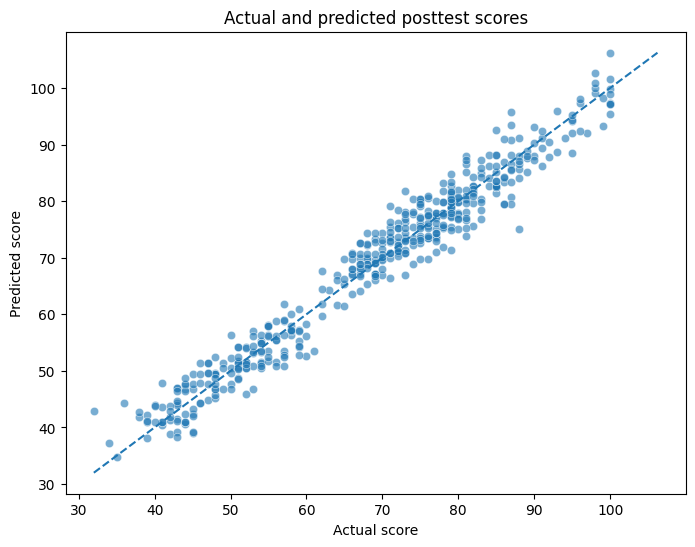

In [29]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=results,
    x="ActualPosttest",
    y="PredictedPosttest",
    alpha=0.6
)

minimum_score = min(
    results["ActualPosttest"].min(),
    results["PredictedPosttest"].min()
)

maximum_score = max(
    results["ActualPosttest"].max(),
    results["PredictedPosttest"].max()
)

plt.plot(
    [minimum_score, maximum_score],
    [minimum_score, maximum_score],
    linestyle="--"
)

plt.title("Actual and predicted posttest scores")
plt.xlabel("Actual score")
plt.ylabel("Predicted score")
plt.show()


Most points are close to the ideal prediction line. This means that predicted scores are close to actual scores.

The largest deviations should be analysed separately because they may represent students whose final result was unusual compared with their initial score.


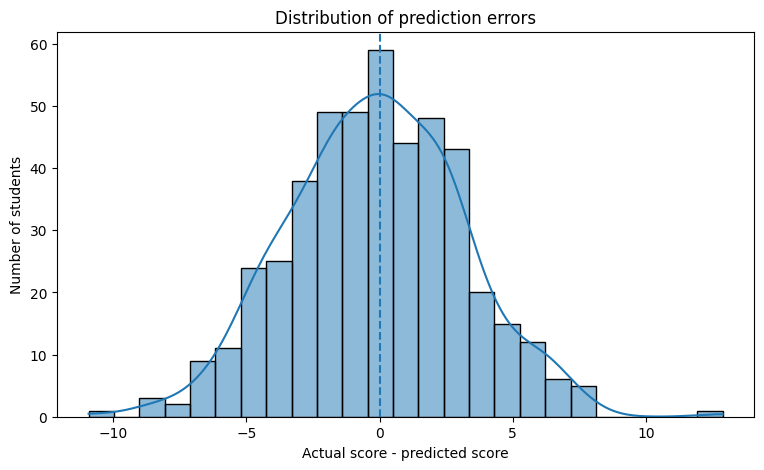

In [30]:
plt.figure(figsize=(9, 5))

sns.histplot(
    results["ActualPosttest"]
    - results["PredictedPosttest"],
    bins=25,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribution of prediction errors")
plt.xlabel("Actual score - predicted score")
plt.ylabel("Number of students")
plt.show()


Errors are concentrated around zero, which means that the model does not show a clear tendency to systematically overestimate or underestimate scores.


# Students Requiring Support


In [31]:
SUPPORT_THRESHOLD = 60

results["ActualRisk"] = (
    results["ActualPosttest"] < SUPPORT_THRESHOLD
).astype(int)

results["PredictedRisk"] = (
    results["PredictedPosttest"] < SUPPORT_THRESHOLD
).astype(int)

risk_summary = pd.crosstab(
    results["ActualRisk"],
    results["PredictedRisk"],
    rownames=["Actual risk"],
    colnames=["Predicted risk"]
)

risk_summary


Predicted risk,0,1
Actual risk,,
0,308,5
1,3,148


The regression model can be used not only to predict a numerical score but also to create a list of students who may need support.

The 60-point threshold is only a demonstration example. In a real school, it should be defined together with teachers and depend on the test scale and educational requirements.


In [32]:
ranking = results.sort_values(
    "PredictedPosttest"
)

number_of_students = int(
    np.ceil(len(ranking) * 0.20)
)

selected_students = ranking.head(
    number_of_students
)

precision_at_20 = (
    selected_students["ActualRisk"].mean()
)

recall_at_20 = (
    selected_students["ActualRisk"].sum()
    / ranking["ActualRisk"].sum()
)

print("Precision@20%:", precision_at_20)
print("Recall@20%:", recall_at_20)


Precision@20%: 1.0
Recall@20%: 0.6158940397350994


This analysis answers the question: how many truly at-risk students are included among the 20% of learners identified by the model as most in need of support?

This is a more practical evaluation than comparing models only through R².


# Feature Importance


In [33]:
importance = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance


,Feature,Importance
6,pretest,13.619877
2,teaching_method,1.133598
5,n_student,0.044633
4,lunch,0.038181
3,gender,0.002764
1,school_type,-0.004051
0,school_setting,-0.007638


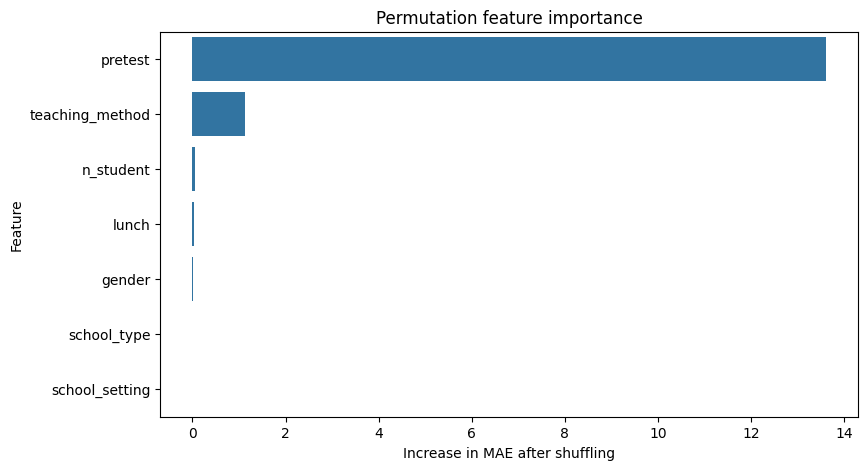

In [34]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Permutation feature importance")
plt.xlabel("Increase in MAE after shuffling")
plt.ylabel("Feature")
plt.show()


The pretest score is the most important feature. The remaining variables contribute much less to prediction quality.

This is an important practical conclusion: a simple system based mainly on the initial score may work almost as well as a more complex model.

Feature importance does not prove causality.


# Error Analysis


In [35]:
largest_errors = (
    results
    .sort_values(
        "AbsoluteError",
        ascending=False
    )
    .head(20)
)

largest_errors


,school_setting,school_type,teaching_method,gender,lunch,n_student,pretest,ActualPosttest,PredictedPosttest,AbsoluteError,ActualRisk,PredictedRisk
850,Urban,Non-public,Standard,Male,Does not qualify,22.0,66.0,88.0,75.121829,12.878171,0,0
740,Urban,Public,Standard,Female,Qualifies for reduced/free lunch,28.0,32.0,32.0,42.922066,10.922066,1,1
1464,Suburban,Public,Standard,Female,Does not qualify,21.0,72.0,73.0,81.833964,8.833964,0,0
866,Urban,Non-public,Experimental,Male,Does not qualify,21.0,82.0,87.0,95.783637,8.783637,0,0
728,Urban,Public,Standard,Female,Qualifies for reduced/free lunch,24.0,33.0,36.0,44.243927,8.243927,1,1
1661,Suburban,Non-public,Standard,Female,Does not qualify,20.0,69.0,71.0,79.062630,8.062630,0,0
1412,Suburban,Public,Standard,Male,Does not qualify,23.0,61.0,79.0,71.398531,7.601469,0,0
816,Urban,Public,Experimental,Male,Qualifies for reduced/free lunch,26.0,37.0,61.0,53.455127,7.544873,0,1
1637,Suburban,Non-public,Experimental,Male,Does not qualify,16.0,77.0,85.0,92.538989,7.538989,0,0
886,Urban,Non-public,Standard,Female,Does not qualify,17.0,70.0,87.0,79.473324,7.526676,0,0


The largest errors may concern students who performed much better or much worse than their pretest suggested.

This may be related to progress, motivation, absence, additional support, or other factors not included in the dataset.

These cases show why the model should not replace teacher judgement.


# Recommendations


1. Linear Regression can be used as the main model because it achieves the best result and is easy to explain.
2. The pretest score is the most important information for predicting the final result.
3. The model can create a list of students with the lowest predicted scores so that teachers can plan additional support.
4. Predictions should be presented together with the typical error of about 2.6 points.
5. The model should not automatically assign students to groups or make educational decisions.
6. Future work should add attendance, activity, completed assignments, and score changes over time.


# Summary

Linear Regression achieves the best result. The model obtains an MAE of approximately 2.59 points and an R² of approximately 0.96 on schools not included in the training set.

The pretest score is the most important feature. More complex models do not improve performance, so the simpler model is the better choice.

The model can support teachers in identifying students at risk of a low score, but it should be treated as a support tool rather than an automatic decision-making system.
